In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier

In [2]:
dig=load_digits()
df=pd.DataFrame(dig.data,dig.target)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [3]:
df['target'] = dig.target
print(df)

      0    1     2     3     4     5    6    7    8    9  ...   55   56   57  \
0   0.0  0.0   5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1   0.0  0.0   0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2   0.0  0.0   0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3   0.0  0.0   7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  0.0  0.0  0.0   
4   0.0  0.0   0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
..  ...  ...   ...   ...   ...   ...  ...  ...  ...  ...  ...  ...  ...  ...   
9   0.0  0.0   4.0  10.0  13.0   6.0  0.0  0.0  0.0  1.0  ...  0.0  0.0  0.0   
0   0.0  0.0   6.0  16.0  13.0  11.0  1.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
8   0.0  0.0   1.0  11.0  15.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
9   0.0  0.0   2.0  10.0   7.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
8   0.0  0.0  10.0  14.0   8.0   1.0  0.0  0.0  0.0  2.0  ...  0.0  0.0  1.0   

     58    59    60    61   62   63  ta

In [4]:
df['target'].value_counts()

target
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64

In [6]:
X= df.drop(columns='target', axis = 1)
Y= df['target']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=10)
knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")

In [7]:
knn.fit(X_train, Y_train)
print("Model Accuracy:", knn.score(X_test, Y_test))

Model Accuracy: 0.9907407407407407


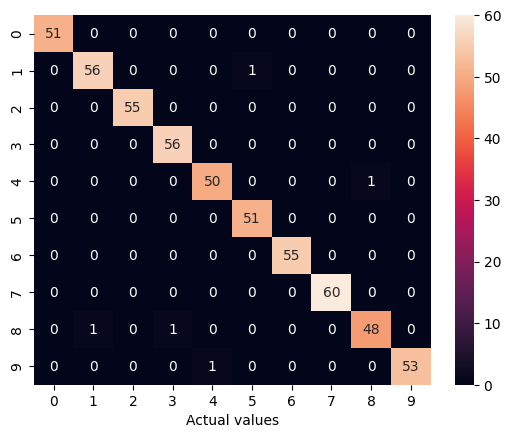

In [8]:
pred_Y = knn.predict(X_test)
cm = confusion_matrix(Y_test, pred_Y)
sns.heatmap(cm,annot=True, fmt='d')
plt.xlabel("Predeiction values")
plt.xlabel("Actual values")
plt.show()



In [9]:
k_range = range(3, 40)
er = []
for i in k_range:
    knn = KNeighborsClassifier(n_neighbors = i,metric='euclidean')
    knn.fit(X_train, Y_train)
    pred_i = knn.predict(X_test)
    er.append(np.mean(pred_i != Y_test))

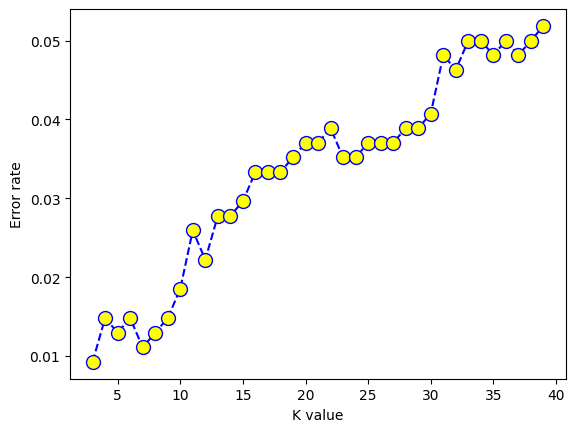

In [10]:
plt.plot(k_range, er, color='blue', linestyle='dashed', marker='o', markerfacecolor='yellow', markersize=10)
plt.xlabel("K value")
plt.ylabel("Error rate")
plt.show()

In [11]:
opt_k = k_range[np.argmin(er)]
print(opt_k)

3
